In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device: {device}')

device: cuda


In [2]:
classes = ['airplane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])
test_transform = transforms.Compose([ #no agumentation for test
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])
full_train = torchvision.datasets.CIFAR10(root='./data', train=True,
                                           download=True, transform=train_transform)
test_set=torchvision.datasets.CIFAR10(root='./data', train=False,
                                           download=True, transform=test_transform)

train_set,val_set=torch.utils.data.random_split(full_train, [45000, 5000])
train_loader=torch.utils.data.DataLoader(train_set, batch_size=128,
                                            shuffle=True, num_workers=2)
val_loader=torch.utils.data.DataLoader(val_set,   batch_size=128,
                                            shuffle=False, num_workers=2)
test_loader=torch.utils.data.DataLoader(test_set,  batch_size=128,
                                            shuffle=False, num_workers=2)

print(f'train: {len(train_set)}  val: {len(val_set)}  test: {len(test_set)}')

c:\Users\sarat\miniconda3\envs\gp-env\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


train: 45000  val: 5000  test: 10000


In [3]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)  
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.classifier(x)
        return x

model = SimpleCNN().to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f'total parameters: {total_params:,}')

SimpleCNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_feat

In [4]:
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(), lr=0.001)
epochs=50
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

In [5]:
train_losses, val_losses = [], []
train_accs, val_accs = [], []
best_valacc = 0.0
for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / len(train_loader)
        train_acc = 100. * correct / total

        model.eval()
        val_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                correct += predicted.eq(labels).sum().item()
                total += labels.size(0)

        val_loss = val_loss / len(val_loader)
        val_acc = 100. * correct / total

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        if val_acc > best_valacc:
            best_valacc = val_acc
            torch.save(model.state_dict(), 'best_model.pth')
        scheduler.step()

        print(f'epoch [{epoch+1:2d}/{epochs}] '
              f'train loss: {train_loss:.4f} train acc: {train_acc:.2f}% '
              f'val loss: {val_loss:.4f} val acc: {val_acc:.2f}%')
print(f'best validation acuracy: {best_valacc:.2f}%')


epoch [ 1/50] train loss: 1.6475 train acc: 38.58% val loss: 1.6233 val acc: 43.48%
epoch [ 2/50] train loss: 1.3365 train acc: 51.48% val loss: 1.2881 val acc: 54.68%
epoch [ 3/50] train loss: 1.1841 train acc: 57.26% val loss: 1.1349 val acc: 60.62%
epoch [ 4/50] train loss: 1.0975 train acc: 60.93% val loss: 1.0687 val acc: 61.62%
epoch [ 5/50] train loss: 1.0418 train acc: 63.08% val loss: 1.0227 val acc: 63.74%
epoch [ 6/50] train loss: 0.9870 train acc: 65.13% val loss: 0.9457 val acc: 66.44%
epoch [ 7/50] train loss: 0.9449 train acc: 66.56% val loss: 0.8999 val acc: 69.04%
epoch [ 8/50] train loss: 0.9066 train acc: 67.99% val loss: 0.8797 val acc: 69.58%
epoch [ 9/50] train loss: 0.8786 train acc: 69.30% val loss: 0.9720 val acc: 67.18%
epoch [10/50] train loss: 0.8508 train acc: 70.24% val loss: 0.8578 val acc: 70.54%
epoch [11/50] train loss: 0.8289 train acc: 70.83% val loss: 0.7837 val acc: 72.50%
epoch [12/50] train loss: 0.8051 train acc: 71.74% val loss: 0.8307 val acc:

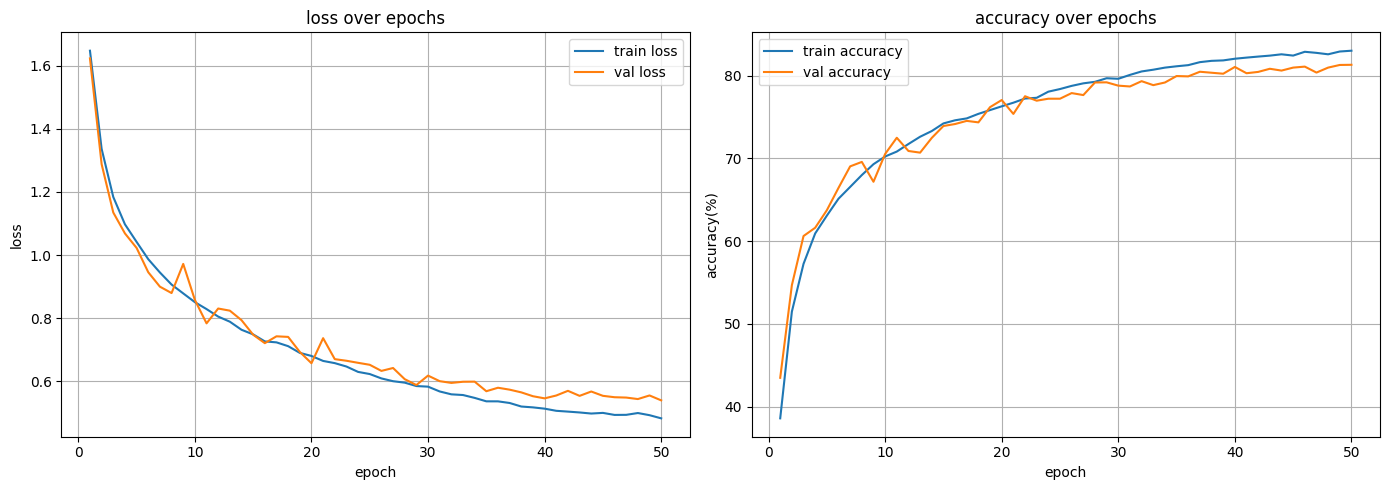

In [6]:
epochs = range(1, len(train_losses) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
#loss curve
ax1.plot(epochs, train_losses, label='train loss')
ax1.plot(epochs, val_losses, label='val loss')
ax1.set_title('loss over epochs')
ax1.set_xlabel('epoch')
ax1.set_ylabel('loss')
ax1.legend()
ax1.grid(True)
#acc curve
ax2.plot(epochs,train_accs,label='train accuracy')
ax2.plot(epochs,val_accs,label='val accuracy')
ax2.set_title('accuracy over epochs')
ax2.set_xlabel('epoch')
ax2.set_ylabel('accuracy(%)')
ax2.legend()
ax2.grid(True)
plt.tight_layout()
plt.show()

In [7]:
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

all_preds,all_labels=[],[]
correct,total=0,0

with torch.no_grad():
    for images,labels in test_loader:
        images,labels=images.to(device), labels.to(device)
        outputs=model(images)
        _, predicted=outputs.max(1)
        correct+=predicted.eq(labels).sum().item()
        total+=labels.size(0)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = 100. *correct/total
print(f'test acc: {test_acc:.2f}%')

test acc: 84.08%


In [8]:
all_preds=np.array(all_preds)
all_labels=np.array(all_labels)

print('per class acc:')
print('--------------------------------')
for i, cls in enumerate(classes):
    mask = all_labels == i
    acc=100. *(all_preds[mask] == i).sum()/mask.sum()
    print(f'{cls:10s}: {acc:.2f}%')

per class acc:
--------------------------------
airplane  : 89.00%
car       : 93.10%
bird      : 75.60%
cat       : 68.50%
deer      : 82.50%
dog       : 74.20%
frog      : 88.50%
horse     : 87.50%
ship      : 91.70%
truck     : 90.20%


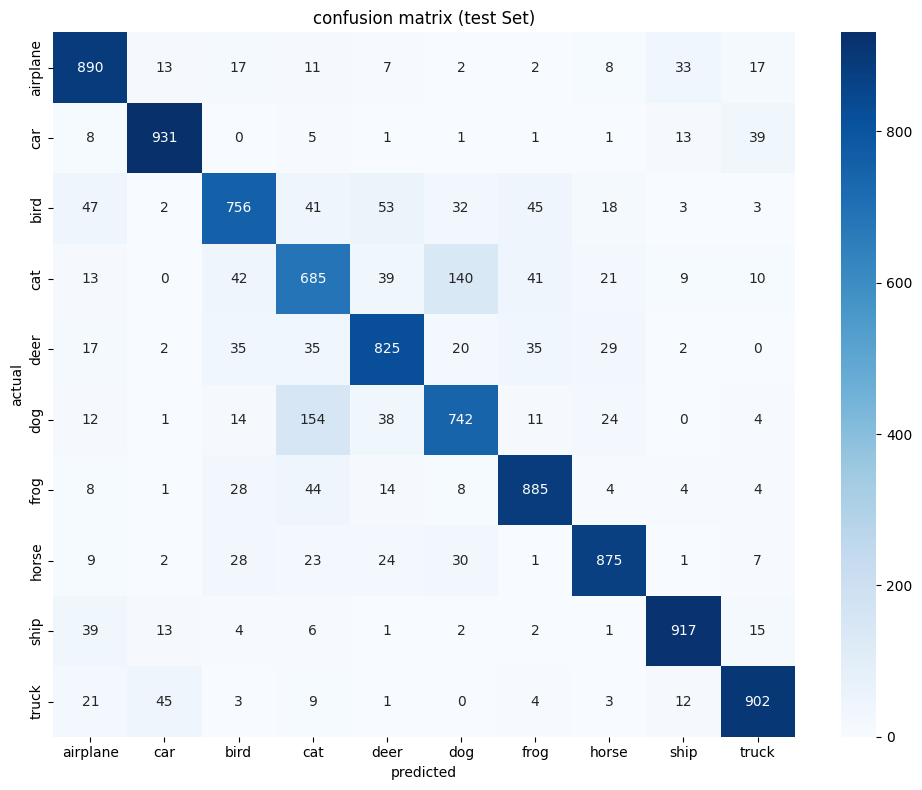

In [9]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('confusion matrix (test Set)')
plt.xlabel('predicted')
plt.ylabel('actual')
plt.tight_layout()
plt.show()

In [12]:
model = SimpleCNN()
model.load_state_dict(torch.load('best_model.pth'))
model.eval()
print(f'final test acc: {test_acc:.2f}%')
print(f'best val acc:   {best_valacc:.2f}%')

final test acc: 84.08%
best val acc:   81.32%
